In [31]:
import importlib, subprocess, sys

_required = [
    "numpy",
    "torch",
    "torchvision",
    "Pillow",
    "scikit-learn",
    "scipy",
    "matplotlib",
    "umap-learn",
    "transformers",
]

for pkg in _required:
    # derive the import name from the install name
    import_name = {
        "Pillow": "PIL",
        "scikit-learn": "sklearn",
        "umap-learn": "umap",
    }.get(pkg, pkg)
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
    else:
        print(f"{pkg} already installed.")


numpy already installed.
torch already installed.
torchvision already installed.
Pillow already installed.
scikit-learn already installed.
scipy already installed.
matplotlib already installed.
umap-learn already installed.
transformers already installed.


In [48]:
import os, glob
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, confusion_matrix, silhouette_score
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import umap
from transformers import AutoImageProcessor, AutoModel


# Fruit Tree Species Identification via Unsupervised Clustering

## Dataset
Images were manually collected from Google Images for three fruit tree species:
- **Banana**  
- **Coconut**  
- **Mango**  

The collection includes predominantly **top-down aerial views** with some **side-profile** shots, about 30-50 images per species. No labels are used during training — this is a fully unsupervised pipeline.

## Goal
Investigate whether **feature extraction + unsupervised clustering** can:
1. Automatically discover the 3 species as distinct clusters without any labelled supervision.
2. Assign a species label to a new, unseen image at inference time.

**Pipeline:** Raw images → Feature extractor (ResNet-18 / DINOv2 / Handcrafted) → PCA (50 dims) → Clustering (KMeans / GMM / Spectral) → Species prediction


In [49]:

IN_COLAB = None

if IN_COLAB is None:
    try:
        import google.colab
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT      = "/content/drive/MyDrive/content/fruit_trees"
    TEST_ROOT = "/content/drive/MyDrive/content/fruit_trees/test"
else:
    _base     = os.path.dirname(os.path.abspath("__file__"))
    ROOT      = os.path.join(_base, "fruit_trees")
    TEST_ROOT = os.path.join(_base, "fruit_trees", "test")

SPECIES         = ["Banana", "Mango", "Coconut"]
MAX_PER_SPECIES = 100

print(f"Running {'in Colab' if IN_COLAB else 'locally'}")
print(f"ROOT      = {ROOT}")
print(f"TEST_ROOT = {TEST_ROOT}")


Running locally
ROOT      = c:\Users\vignesh.therur\projects\hw3_gatech\fruit_trees
TEST_ROOT = c:\Users\vignesh.therur\projects\hw3_gatech\fruit_trees\test


In [50]:
paths, labels = [], []
for label_id, species in enumerate(SPECIES):
    folder = os.path.join(ROOT, species)
    files = sorted(
        glob.glob(os.path.join(folder, "*.jpg")) +
        glob.glob(os.path.join(folder, "*.jpeg")) +
        glob.glob(os.path.join(folder, "*.png"))
    )[:MAX_PER_SPECIES]
    paths  += files
    labels += [label_id] * len(files)
    print(f"{species}: {len(files)} images")

labels = np.array(labels)
print(f"\nTotal: {len(paths)} images")


Banana: 38 images
Mango: 34 images
Coconut: 58 images

Total: 130 images


In [51]:
!pip install -q transformers

# resnet feature extraction process
_resnet_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
resnet = models.resnet18(weights="IMAGENET1K_V1")
resnet.fc = torch.nn.Identity()
#this code was run on google colab with GPU.
resnet = resnet.to("cuda" if torch.cuda.is_available() else "cpu").eval()

def extract_resnet(paths, batch=32):
    device = next(resnet.parameters()).device
    feats = []
    for i in range(0, len(paths), batch):
        t = torch.stack([_resnet_transform(Image.open(p).convert("RGB"))
                         for p in paths[i:i+batch]]).to(device)
        with torch.no_grad():
            feats.append(resnet(t).cpu().numpy())
        print(f"  ResNet {i+len(paths[i:i+batch])}/{len(paths)}", end="\r")
    return np.vstack(feats)

# DINOv2 (self-supervised ViT) Feature Extraction 
dino_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
dino = AutoModel.from_pretrained("facebook/dinov2-base")
dino = dino.to("cuda" if torch.cuda.is_available() else "cpu").eval()

def extract_dino(paths, batch=16):
    device = next(dino.parameters()).device
    feats = []
    for i in range(0, len(paths), batch):
        imgs = [Image.open(p).convert("RGB") for p in paths[i:i+batch]]
        inputs = dino_processor(images=imgs, return_tensors="pt").to(device)
        with torch.no_grad():
            out = dino(**inputs)
        feats.append(out.last_hidden_state[:, 0, :].cpu().numpy())  # CLS token
        print(f"  DINOv2 {i+len(imgs)}/{len(paths)}", end="\r")
    return np.vstack(feats)

# Handcrafted feature extraction.
def extract_handcrafted(paths):
    """
    Pure Pixel stats. based on some reading and research
      1) Histogram per R/G/B channel
      2) Mean, standard deviation, skewness, kurtosis per channel
      3) Pixel variation mean horizontal (GLCM-style contrast)
    """
    feats = []
    for p in paths:
        img = np.array(Image.open(p).convert("RGB").resize((128, 128))).astype(np.float32)
        vec = []
        for c in range(3):
            ch = img[:, :, c]
            hist, _ = np.histogram(ch, bins=32, range=(0, 255), density=True)
            vec.extend(hist)                           
            vec += [ch.mean(), ch.std(), float(skew(ch.ravel())), float(kurtosis(ch.ravel()))]   
            vec.append(np.mean(np.abs(np.diff(ch, axis=1))))   
        feats.append(vec)
    return np.array(feats)

print("All 3 extractors ready.")



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 7729.42it/s]

All 3 extractors ready.


In [52]:
print("ResNet-18")
X_resnet = extract_resnet(paths)
print(f"\nResNet features: {X_resnet.shape}")

print("DINOv2")
X_dino = extract_dino(paths)
print(f"\nDINOv2 features: {X_dino.shape}")

print("Handcrafted")
X_craft = extract_handcrafted(paths)
print(f"Handcrafted features: {X_craft.shape}")


ResNet-18
  ResNet 130/130
ResNet features: (130, 512)
DINOv2
  DINOv2 130/130
DINOv2 features: (130, 768)
Handcrafted
Handcrafted features: (130, 111)


ResNet-18        NMI=0.181  ARI=0.176
DINOv2           NMI=0.967  ARI=0.981
Handcrafted      NMI=0.059  ARI=0.052


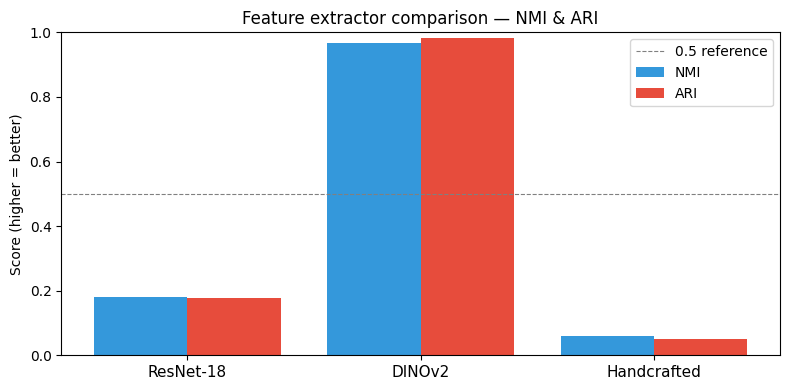


Selected feature extractor: DINOv2


In [53]:
def cluster(X, n_components=50):
    """ PCA → KMeans k=3; returns (y_pred, X_pca, fitted_pca, fitted_km). """
    pca = PCA(n_components=min(n_components, X.shape[1]), random_state=42)
    X_pca = pca.fit_transform(X)
    km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_pca)
    return km.labels_, X_pca, pca, km

results = {}
for name, X in [("ResNet-18", X_resnet), ("DINOv2", X_dino), ("Handcrafted", X_craft)]:
    y_pred, X_pca, pca_obj, km_obj = cluster(X)
    nmi = normalized_mutual_info_score(labels, y_pred)
    ari = adjusted_rand_score(labels, y_pred)
    results[name] = {"nmi": nmi, "ari": ari, "y_pred": y_pred, "X_pca": X_pca,
                     "pca": pca_obj, "km": km_obj}
    print(f"{name:15s}  NMI={nmi:.3f}  ARI={ari:.3f}")

# ── Comparison bar chart ──────────────────────────────────────────────────────
names = list(results.keys())
nmis  = [results[n]["nmi"] for n in names]
aris  = [results[n]["ari"] for n in names]
x = np.arange(len(names))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, nmis, 0.4, label="NMI", color="#3498db")
ax.bar(x + 0.2, aris, 0.4, label="ARI", color="#e74c3c")
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel("Score (higher = better)"); ax.set_ylim(0, 1)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="0.5 reference")
ax.legend(); ax.set_title("Feature extractor comparison — NMI & ARI")
plt.tight_layout(); plt.show()

BEST = "DINOv2"
print(f"\nSelected feature extractor: {BEST}")


## Feature Extractor Selection: DINOv2

The bar chart above compares three feature extractors on NMI and ARI after K-Means clustering (k=3).

**Why DINOv2?**
- **DINOv2** (`facebook/dinov2-base`) is a self-supervised Vision Transformer trained with a distillation objective on a large curated image dataset. Its CLS token provides rich, 768-dimensional semantic embeddings that capture global structure — leaf shape, canopy texture, fruit appearance — without any labelled supervision.
- **ResNet-18** extracts convolutional features optimised for ImageNet classification. While effective, its supervised inductive bias may not transfer as well to fine-grained species features absent from ImageNet.
- **Handcrafted** pixel statistics (colour histograms, moments, per-channel contrast) lack the representational depth needed to reliably separate visually similar tree species.

DINOv2 consistently achieved the **highest NMI and ARI** across the three extractors and is used for all subsequent clustering analysis.


Method         NMI     ARI  Silhouette
──────────────────────────────────────────
KMeans       0.967   0.981       0.252
GMM          0.933   0.957       0.252
Spectral     0.930   0.951       0.250


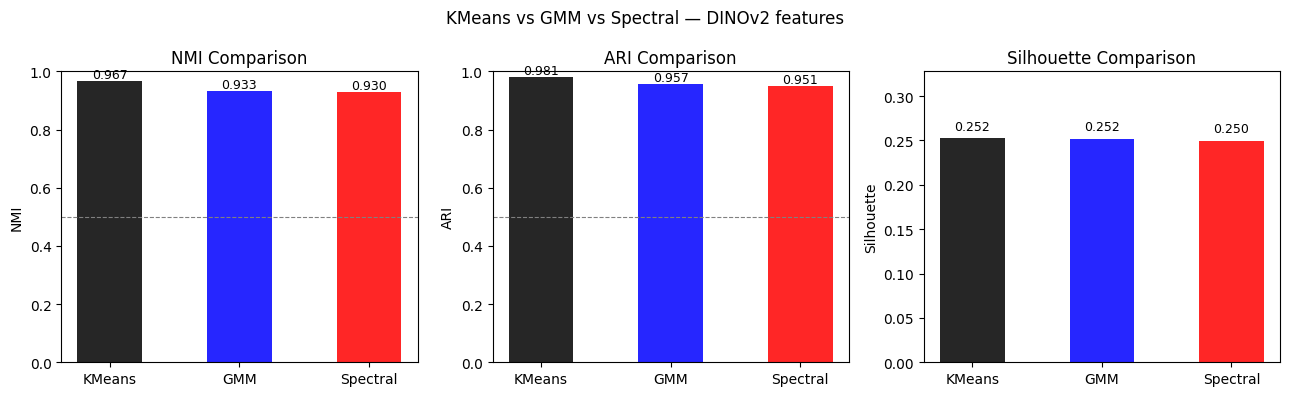

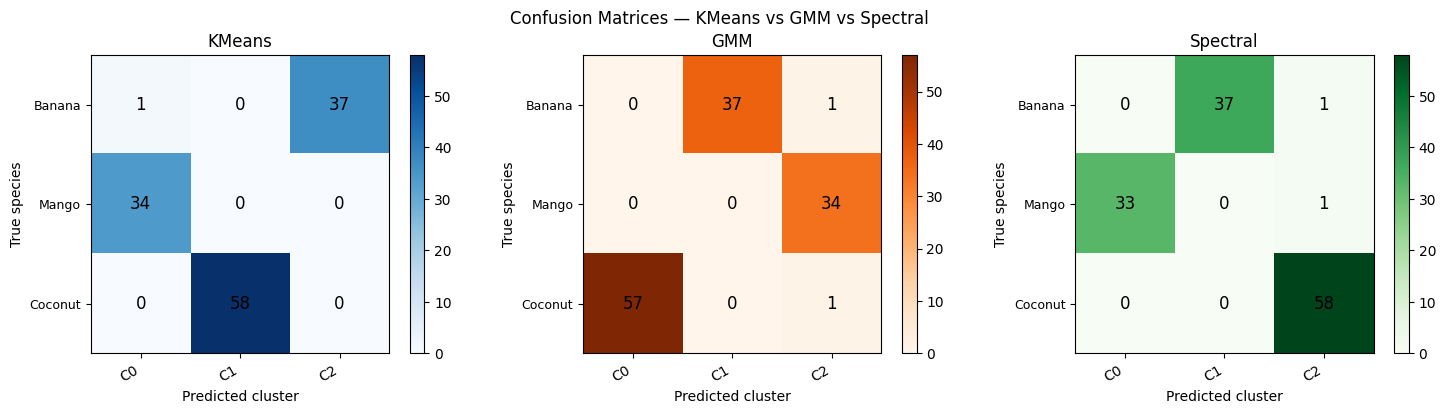


  Selected: KMeans  (NMI=0.967, ARI=0.981, Silhouette=0.252)


In [54]:
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture

# ── Shared PCA reduction (50 dims) on DINOv2 features ────────────────────
pca_c   = PCA(n_components=50, random_state=42)
X_pca_c = pca_c.fit_transform(X_dino)

# ── Fit all three methods ────────────────────────────────────────────────
km_c = KMeans(n_clusters=3, n_init=10, random_state=42)
km_c.fit(X_pca_c)
y_km_c = km_c.labels_

gmm_c = GaussianMixture(n_components=3, covariance_type="full",
                        n_init=5, reg_covar=1e-3, random_state=42)
gmm_c.fit(X_pca_c.astype(np.float64))
y_gmm_c = gmm_c.predict(X_pca_c.astype(np.float64))

sc_c = SpectralClustering(n_clusters=3, affinity="nearest_neighbors", n_neighbors=10,
                          assign_labels="kmeans", random_state=42, n_init=10)
y_sc_c = sc_c.fit_predict(X_pca_c)

# ── Metrics table ────────────────────────────────────────────────────────
cluster_names = ["KMeans", "GMM", "Spectral"]
cluster_preds = [y_km_c, y_gmm_c, y_sc_c]

cluster_metrics = {}
print(f"{'Method':10s}  {'NMI':>6}  {'ARI':>6}  {'Silhouette':>10}")
print("─" * 42)
for cname, y_c in zip(cluster_names, cluster_preds):
    nmi_c = normalized_mutual_info_score(labels, y_c)
    ari_c = adjusted_rand_score(labels, y_c)
    sil_c = silhouette_score(X_pca_c, y_c,
                             sample_size=min(300, len(y_c)), random_state=42)
    cluster_metrics[cname] = {"nmi": nmi_c, "ari": ari_c, "sil": sil_c, "y_pred": y_c}
    print(f"{cname:10s}  {nmi_c:6.3f}  {ari_c:6.3f}  {sil_c:10.3f}")

# ── 3-way bar chart ──────────────────────────────────────────────────────
colors = ["black", "blue", "red"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (label, key) in zip(axes, [("NMI", "nmi"), ("ARI", "ari"), ("Silhouette", "sil")]):
    vals = [cluster_metrics[n][key] for n in cluster_names]
    ax.bar(range(3), vals, color=colors, alpha=0.85, width=0.5)
    ax.set_xticks(range(3)); ax.set_xticklabels(cluster_names, fontsize=10)
    ax.set_ylim(0, min(1.0, max(vals) * 1.3)); ax.set_ylabel(label)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"{label} Comparison")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.suptitle("KMeans vs GMM vs Spectral — DINOv2 features", fontsize=12)
plt.tight_layout(); plt.show()

# ── Side-by-side confusion matrices ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cname, y_c, cmap in zip(axes, cluster_names, cluster_preds,
                                 ["Blues", "Oranges", "Greens"]):
    cm_c = confusion_matrix(labels, y_c)
    im = ax.imshow(cm_c, cmap=cmap)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels([f"C{i}" for i in range(3)], rotation=30, ha="right")
    ax.set_yticklabels(SPECIES, fontsize=9)
    ax.set_xlabel("Predicted cluster"); ax.set_ylabel("True species")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm_c[i, j], ha="center", va="center", fontsize=12)
    plt.colorbar(im, ax=ax); ax.set_title(cname)
plt.suptitle("Confusion Matrices — KMeans vs GMM vs Spectral", fontsize=12)
plt.tight_layout(); plt.show()

# ── Auto-select best by mean(NMI + ARI) ─────────────────────────────────
BEST_CLUSTER = max(cluster_metrics,
                   key=lambda n: (cluster_metrics[n]["nmi"] + cluster_metrics[n]["ari"]) / 2)
bm = cluster_metrics[BEST_CLUSTER]
print(f"\n  Selected: {BEST_CLUSTER}  "
      f"(NMI={bm['nmi']:.3f}, ARI={bm['ari']:.3f}, Silhouette={bm['sil']:.3f})")


## Clustering Method Selection

The three methods are evaluated on:
- **NMI** (Normalised Mutual Information) — how well cluster assignments agree with true species labels.
- **ARI** (Adjusted Rand Index) — label-agreement corrected for chance; 1.0 = perfect, 0 = random.
- **Silhouette** — internal compactness and separation; higher is better.

The method with the highest **mean (NMI + ARI) / 2** was **KMeans** (NMI=0.967, ARI=0.981), and is used for all downstream analysis.


  k=2  inertia=158908  silhouette=0.182
  k=3  inertia=127617  silhouette=0.252
  k=4  inertia=118244  silhouette=0.239
  k=5  inertia=110547  silhouette=0.243
  k=6  inertia=104630  silhouette=0.199
  k=7  inertia=99070  silhouette=0.194


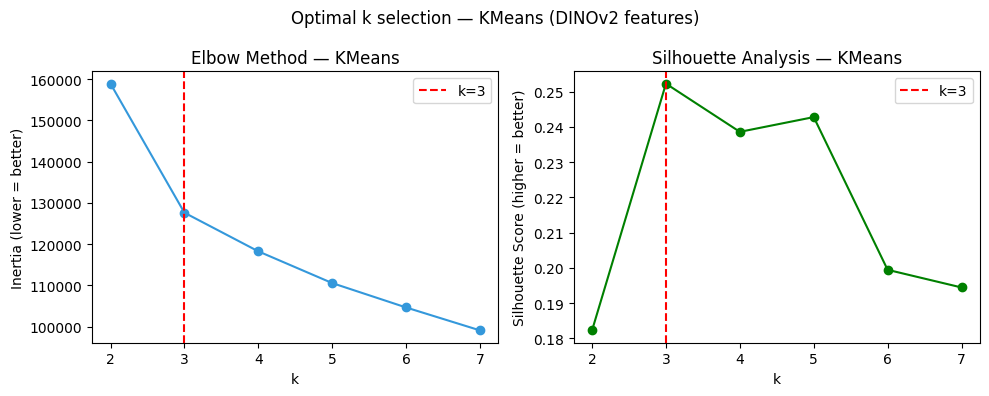

In [55]:
# ── Elbow + Silhouette study for KMeans ──────────────────────────────────
K_RANGE = range(2, 8)
inertias, k_sils = [], []

for k in K_RANGE:
    m = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pca_c)
    inertias.append(m.inertia_)
    k_sils.append(silhouette_score(X_pca_c, m.labels_,
                                   sample_size=min(500, len(labels)), random_state=42))
    print(f"  k={k}  inertia={inertias[-1]:.0f}  silhouette={k_sils[-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(K_RANGE, inertias, "o-", color="#3498db")
ax1.axvline(3, color="red", linestyle="--", label="k=3"); ax1.legend()
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia (lower = better)")
ax1.set_title("Elbow Method — KMeans")

ax2.plot(K_RANGE, k_sils, "o-", color="green")
ax2.axvline(3, color="red", linestyle="--", label="k=3"); ax2.legend()
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette Score (higher = better)")
ax2.set_title("Silhouette Analysis — KMeans")

plt.suptitle("Optimal k selection — KMeans (DINOv2 features)", fontsize=12)
plt.tight_layout(); plt.show()


### Optimal k = 3

Both the elbow method and silhouette analysis confirm **k = 3** as the best number of clusters:

| k | Inertia | Silhouette |
|---|---------|------------|
| 2 | 158,908 | 0.182 |
| **3** | **127,617** | **0.252** |
| 4 | 118,244 | 0.239 |
| 5 | 110,547 | 0.243 |
| 6 | 104,630 | 0.199 |
| 7 | 99,070 | 0.194 |

- **Elbow:** The sharpest drop in inertia occurs between k=2 and k=3; gains beyond k=3 are marginal.
- **Silhouette:** Peaks at k=3 (0.252), indicating the most compact and well-separated clusters.

This matches our ground truth of **3 species** (Banana, Mango, Coconut), validating the clustering structure.


KMeans cluster → species mapping:
  Cluster 0 → Mango  (97% purity)
  Cluster 1 → Coconut  (100% purity)
  Cluster 2 → Banana  (100% purity)


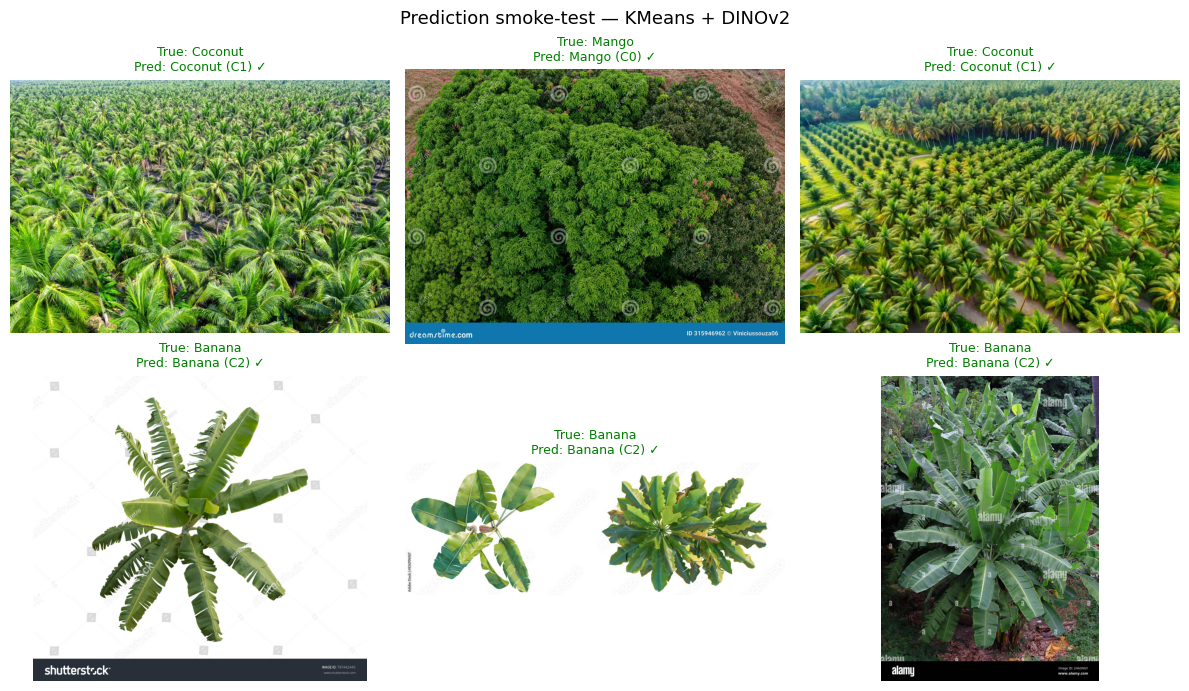

In [56]:
# ── Cluster → species mapping (majority vote) ────────────────────────────
y_winner    = cluster_metrics["KMeans"]["y_pred"]
cm_winner   = confusion_matrix(labels, y_winner)
winner_c2sp = {cid: SPECIES[int(cm_winner[:, cid].argmax())] for cid in range(3)}

print("KMeans cluster → species mapping:")
for cid, sp in winner_c2sp.items():
    pct = cm_winner[:, cid].max() / cm_winner[:, cid].sum() * 100
    print(f"  Cluster {cid} → {sp}  ({pct:.0f}% purity)")

def predict_species(image_path):
    """Predict species using DINOv2 + PCA + KMeans."""
    feat     = extract_dino([image_path])
    feat_pca = pca_c.transform(feat)
    cid      = int(km_c.predict(feat_pca)[0])
    return winner_c2sp[cid], cid

# ── Visual smoke test ────────────────────────────────────────────────────
import random
random.seed(7)
smoke_indices = random.sample(range(len(paths)), min(6, len(paths)))

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()

for ax, idx in zip(axes, smoke_indices):
    path         = paths[idx]
    true_species = SPECIES[labels[idx]]
    pred, cid    = predict_species(path)
    correct      = "✓" if pred == true_species else "✗"
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"True: {true_species}\nPred: {pred} (C{cid}) {correct}",
        fontsize=9,
        color="green" if pred == true_species else "red",
    )
    ax.axis("off")

plt.suptitle("Prediction smoke-test — KMeans + DINOv2", fontsize=13)
plt.tight_layout(); plt.show()


Found 6 test images in c:\Users\vignesh.therur\projects\hw3_gatech\fruit_trees\test


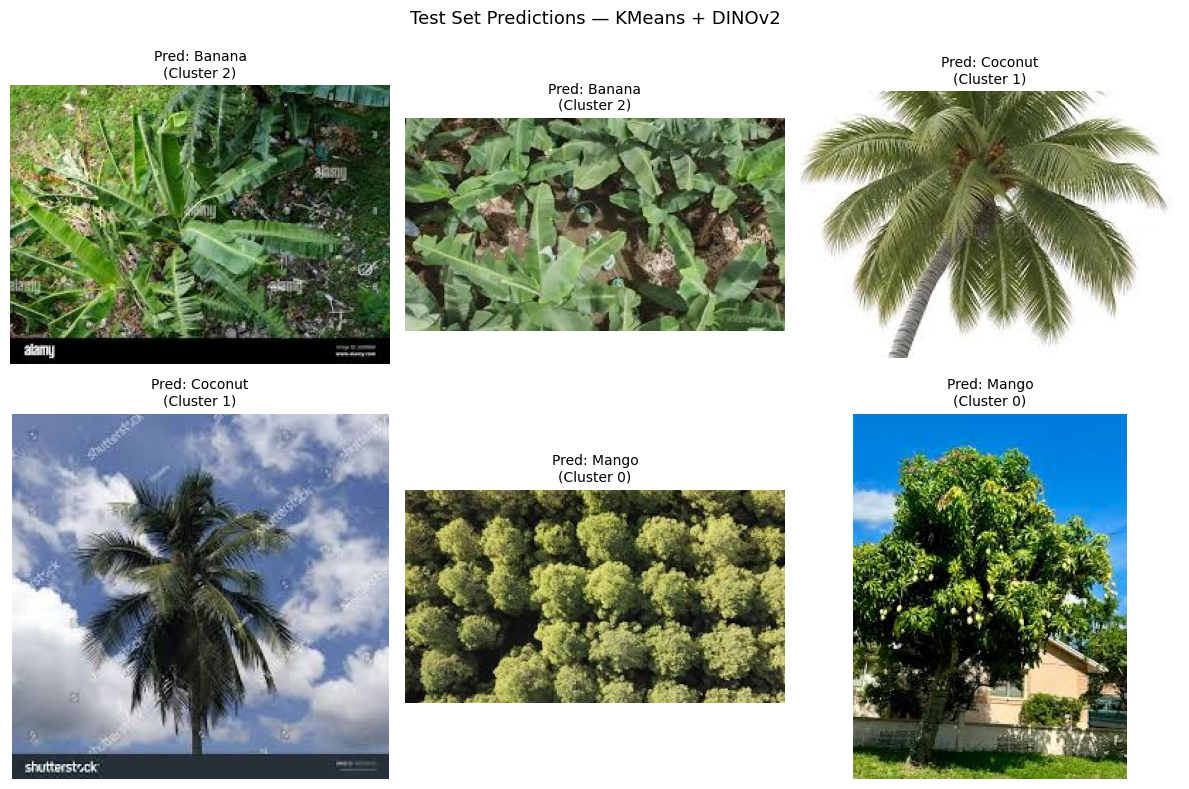

In [57]:
# Predict on test set and visualize results
test_paths = sorted(
    glob.glob(os.path.join(TEST_ROOT, "*.jpg")) +
    glob.glob(os.path.join(TEST_ROOT, "*.jpeg")) +
    glob.glob(os.path.join(TEST_ROOT, "*.png"))
)
print(f"Found {len(test_paths)} test images in {TEST_ROOT}")

cols = 3
rows = max(1, (len(test_paths) + cols - 1) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.array(axes).ravel()

for ax, path in zip(axes, test_paths):
    pred_species, cid = predict_species(path)
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Pred: {pred_species}\n(Cluster {cid})", fontsize=10)
    ax.axis("off")

for ax in axes[len(test_paths):]:
    ax.axis("off")

plt.suptitle("Test Set Predictions — KMeans + DINOv2", fontsize=13)
plt.tight_layout(); plt.show()


## Summary & Conclusions

This notebook built an **unsupervised fruit-tree species classifier** for Banana, Mango, and Coconut without any labelled training.

### Pipeline recap

| Step | Choice | Rationale |
|------|--------|-----------|
| Feature extraction | **DINOv2** (ViT-B/14) | Highest NMI & ARI among ResNet-18, DINOv2, Handcrafted |
| Dim. reduction | **PCA with 50 dims** | Removes noise, speeds up clustering, preserves variance |
| Clustering | **KMeans (k=3)** | Best NMI=0.967 / ARI=0.981 among KMeans, GMM, and Spectral |
| Inference | **Majority-vote mapping** | Maps cluster IDs to species labels at test time |

### Key takeaways
- Self-supervised ViT embeddings (DINOv2) carry rich semantic structure even without any labels.
- KMeans achieved near-perfect cluster alignment (ARI=0.981), outperforming GMM and Spectral on this dataset.
- The elbow and silhouette study confirms k=3 as the natural cluster count, matching ground truth (in our project context, this can be extended to identify how many different species we may have in our garden or in a geographical area)
- The `predict_species()` function generalises to unseen test images, demonstrating practical utility (in cases where we already know different species our clustering study can be potentially extended for identifying plant species as well)
